导数:万物均可流动
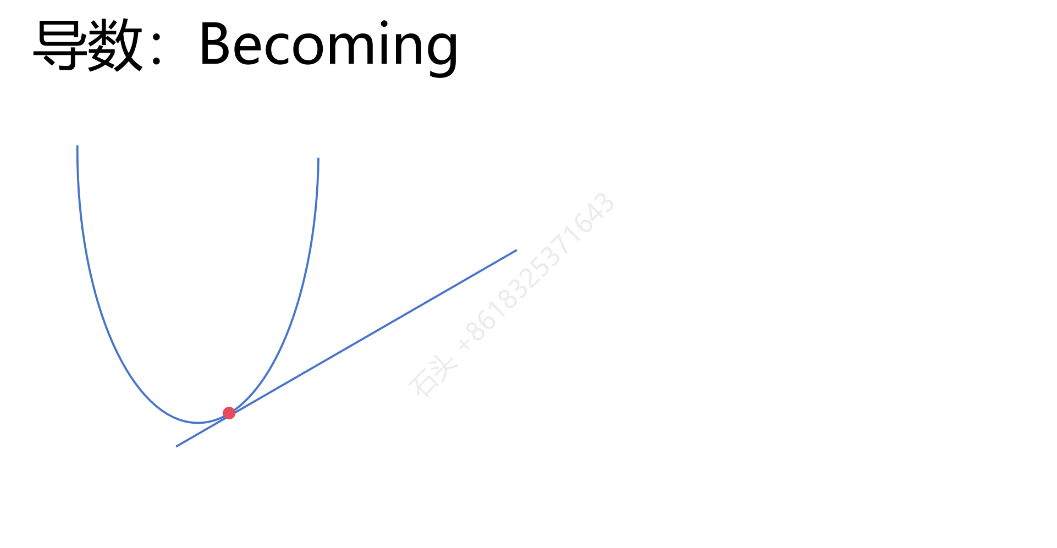

 h -> 0
 启示:
     1. 方向比位置更重要;
     2. 活在当下,但更要看向远方;
     3. 趋势大于现状;
数学世界最为性感的知识模块
他用最为冷静的极限定义了最为"炽热"的变化

求导:
    牛顿与莱布尼茨
    问题:
        探索瞬时速度
        一条曲线在某一点的斜率
    "微积分" 用极限的思想,解决瞬时变化率的问提
    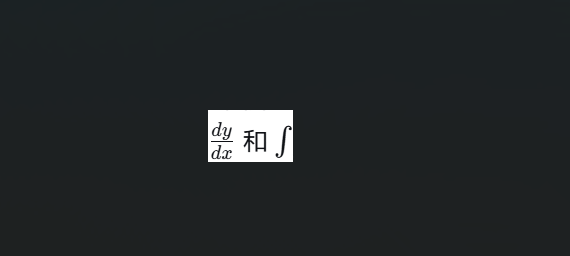
    柯西与极限的严格化
    数值计算code,梯度下降算法Algorithm,底层都依赖"极限"的思想

    趋近与0,不可实现,可以用极小的数替代
    最速下降法


    加速度  如果速度增加,那距离对时间的二阶导数


梯度: 多变量函数的导数,指向函数值增长最快的方向
        min 往梯度的反方向走
     计算机世界里面,处理的问题,不是物理运动, 而是优化问题

         机器学习: 最小化损失函数
         升读学习: 最小化交叉熵
         推荐系统: 最小化预测误差
         量化交易:最大化交易,最小化风险

    求极值,必须用到导数和梯度
    世界充满变化,计算机充满优化

    CV Model Predicate

    方向, 敏感度

为什么需要梯度?
    模型参数太多
        nnw  一亿个参数  无法一个调试 需要一个方向 损失函数下降最快
    梯度就是这个方向
    梯度下降:  参数= 参数- 学习率* 梯度

CS 从数据中寻找规律的
    - 监督学习
    - 无监督学习
    - 强化学习
    - DL(深度学习)
导数的定义:令函数f(x),在x处的导数
    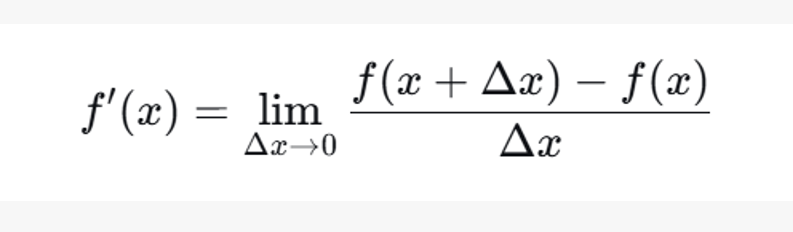
    函数有多个变量: f(x,y)偏导数
    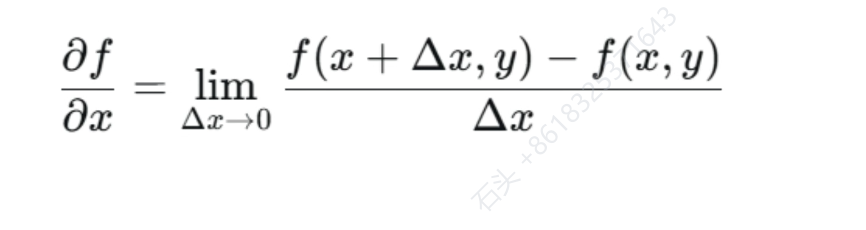
    简单理解就是把其他变量当作常数,只对一个变量求导

梯度 :
    把所有的偏导数放到一起,就是一个向量
    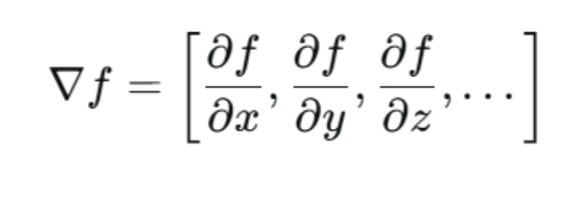
    这个向量就叫梯度
    关键性质:
        - 方向
        - 大小 (梯度的模长)
    要让函数值下降最快,梯度就要沿着负梯度方向走

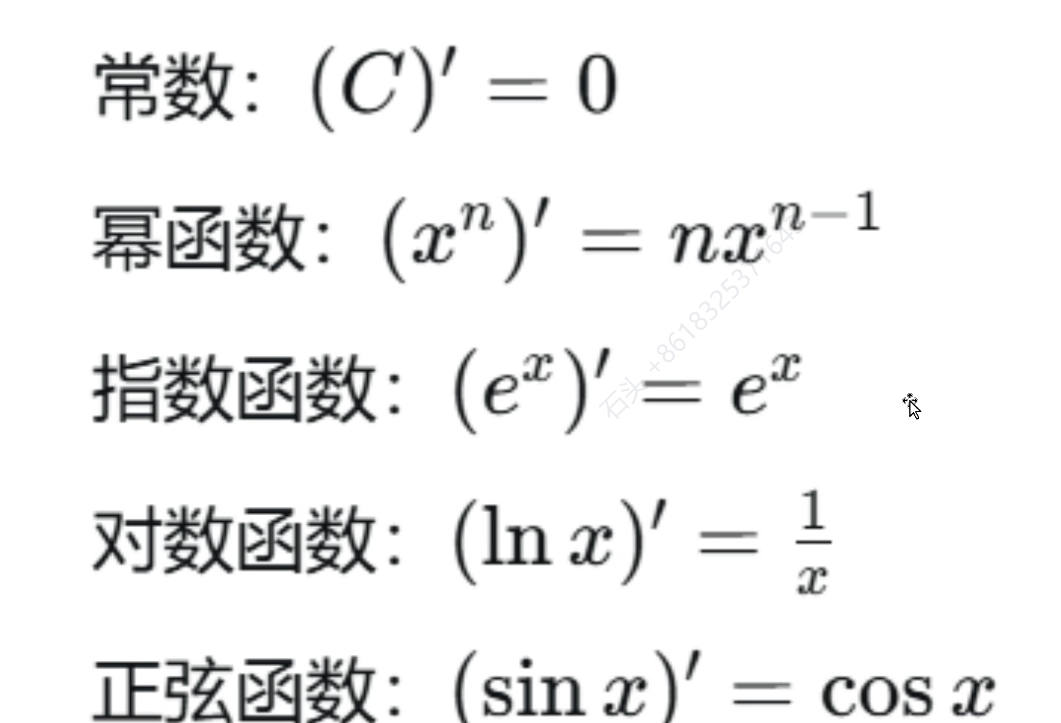
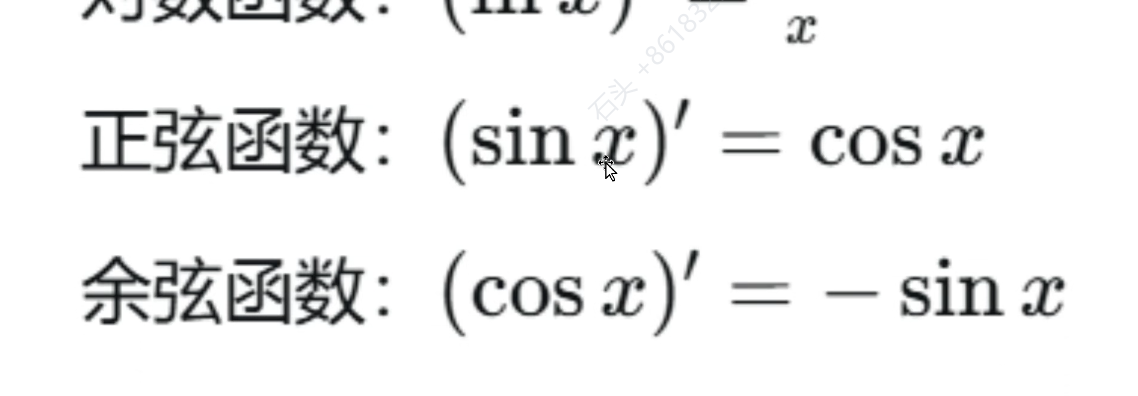
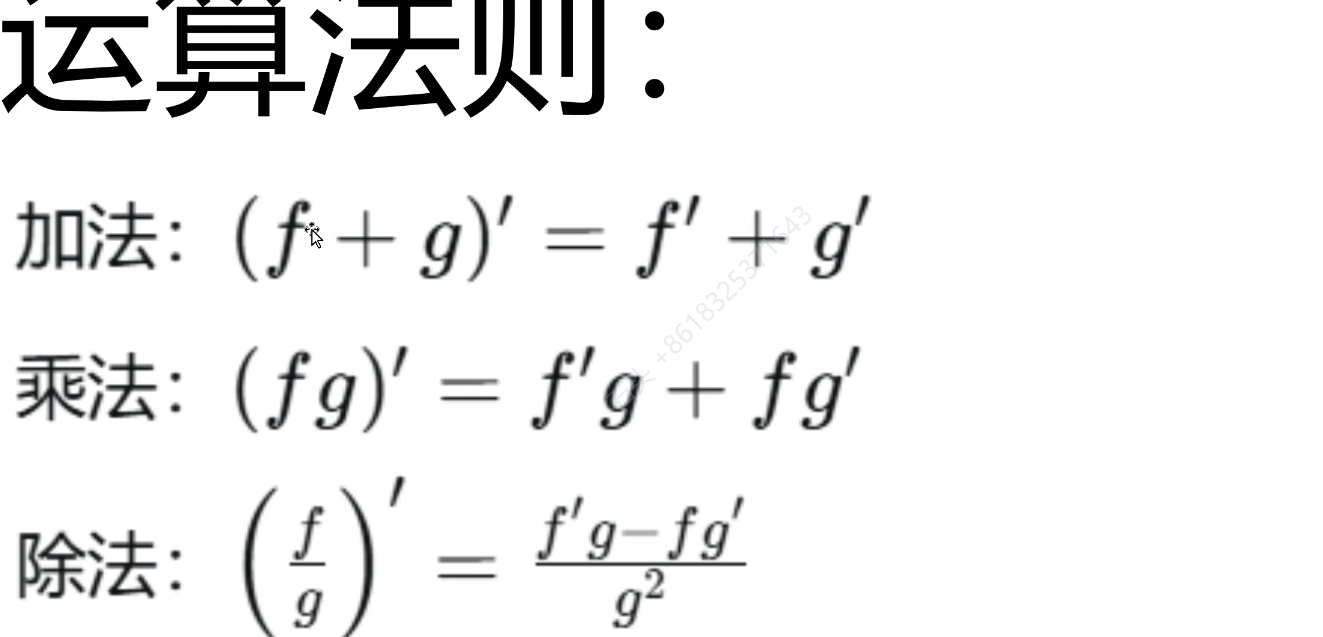
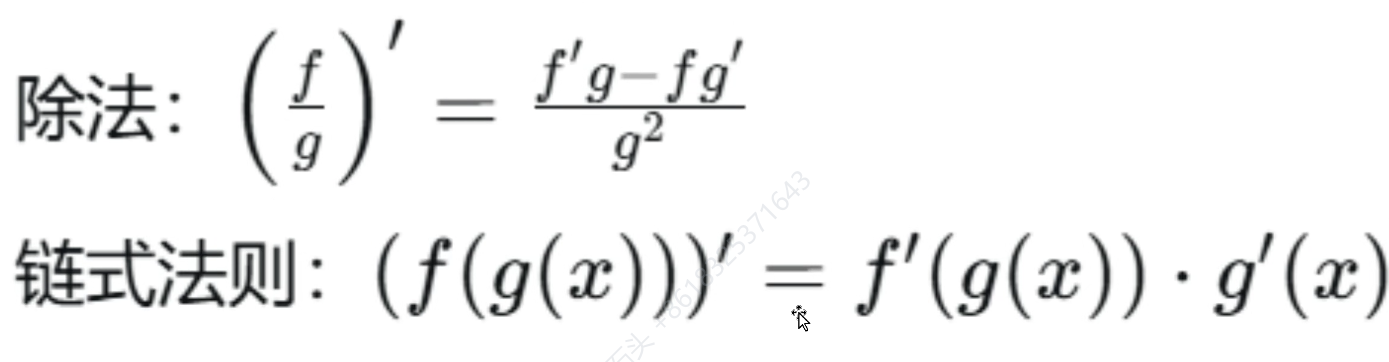
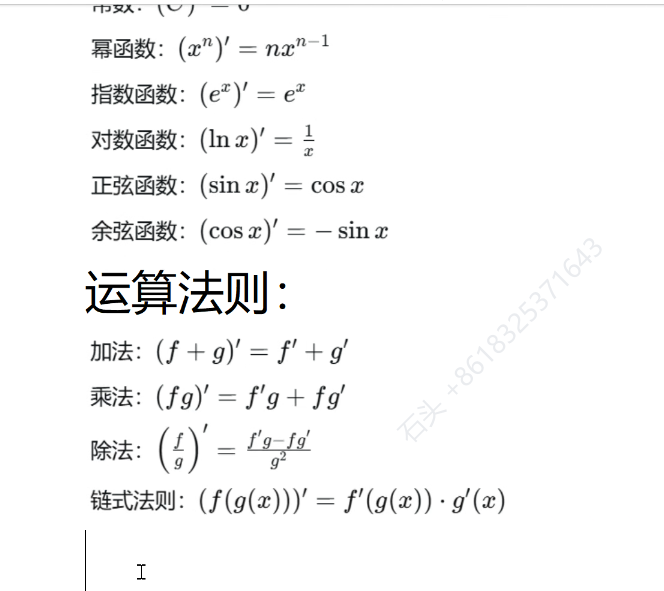

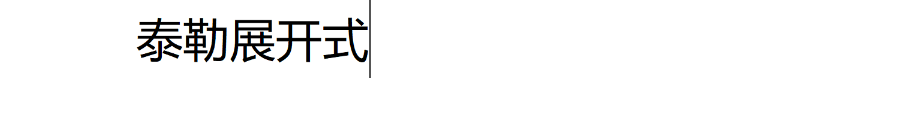

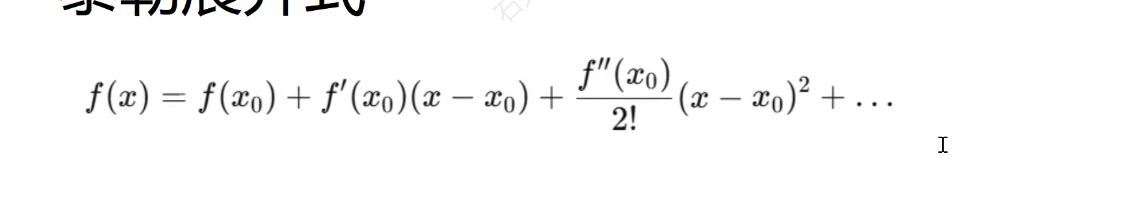








边际成本:  总成本变化量 / 产量变化量


## 导数与梯度


In [48]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [49]:
# 数值求导

def f(x):
    return x ** 2


def f_prime(x):
    return 2 * x


def num_deriv(func, x, h=1e-5):
    return (func(x + h) - func(x)) / h


for x in [0, 1, 2, 3]:
    exact = f_prime(x)
    numeric = num_deriv(f, x)
    print(f"x={x}:,解析={exact},数值= {numeric:.6f},误差={abs(exact - numeric):.6f}")



x=0:,解析=0,数值= 0.000010,误差=0.000010
x=1:,解析=2,数值= 2.000010,误差=0.000010
x=2:,解析=4,数值= 4.000010,误差=0.000010
x=3:,解析=6,数值= 6.000010,误差=0.000010


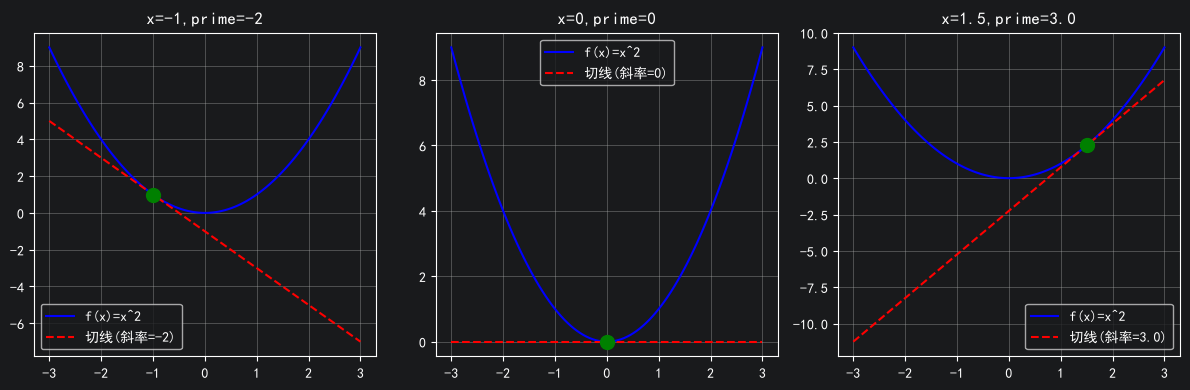

In [55]:
# 可视化

x = np.linspace(-3, 3, 100)
y = x ** 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, x0 in zip(axes, [-1, 0, 1.5]):
    ax.plot(x, y, 'b-', label='f(x)=x^2')
    slope = 2 * x0
    tangent = f(x0) + slope * (x - x0)
    ax.plot(x, tangent, 'r--', label=f'切线(斜率={slope})')
    ax.plot(x0, f(x0), 'go', markersize=10)
    ax.set_title(f'x={x0},prime={slope}')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()


## 偏导数与梯度

In [51]:
def f2(x, y):
    return x ** 2 + 3 * x * y + y ** 2


def df_dx(x, y):
    return 2 * x + 3 * y


def df_dy(x, y):
    return 2 * y + 3 * x


def num_partial(func, x, y, h=1e-5, axis=0):
    if axis == 0:
        return (func(x + h, y) - func(x, y)) / h
    else:
        return (func(x, y + h) - func(x, y)) / h


x0, y0 = 1, 2

print(f'df/dx({x0},{y0}) =解析={df_dx(x0, y0)},数值={num_partial(f2, x0, y0)}')
print(f'df/dy({x0},{y0}) =解析={df_dy(x0, y0)},数值={num_partial(f2, x0, y0, axis=1)}')
print(f"梯度=[{df_dx(x0, y0)},{df_dy(x0, y0)}]")



df/dx(1,2) =解析=8,数值=8.000010000053237
df/dy(1,2) =解析=7,数值=7.000010000091094
梯度=[8,7]


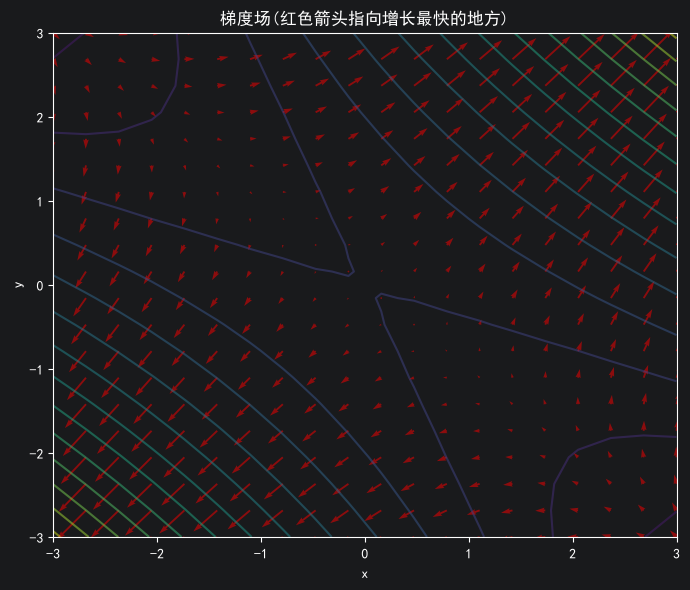

In [52]:
x = np.linspace(-3, 3, 20)
y = np.linspace(-3, 3, 20)

X, Y = np.meshgrid(x, y)
Z = X ** 2 + 3 * X * Y + Y ** 2
U = 2 * X + 3 * Y
V = 3 * X + 2 * Y

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(X, Y, Z, 15, cmap='viridis', alpha=0.5)
ax.quiver(X, Y, U, V, color='red', alpha=0.5)
ax.set_title('梯度场(红色箭头指向增长最快的地方)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()



## 梯度下降

In [53]:
def f3(x, y):
    return x ** 2 + y ** 2


def grad_f3(x, y):
    return np.array([2 * x, 2 * y])


pos = np.array([2.5, 2.5])
lr = 0.1
path = [pos.copy()]

for i in range(50):
    g = grad_f3(pos[0], pos[1])
    pos = pos - lr * g
    path.append(pos.copy())

    if i % 10 == 0:
        print(f"步{i}:pos={pos},loss={f3(pos[0], pos[1])}")

print(f"最终: pos={pos},loss={f3(pos[0], pos[1]):.8f}")

步0:pos=[2. 2.],loss=8.0
步10:pos=[0.21474836 0.21474836],loss=0.09223372036854781
步20:pos=[0.02305843 0.02305843],loss=0.0010633823966279328
步30:pos=[0.00247588 0.00247588],loss=1.2259964326927117e-05
步40:pos=[0.00026585 0.00026585],loss=1.4134776518227085e-07
最终: pos=[3.56811923e-05 3.56811923e-05],loss=0.00000000


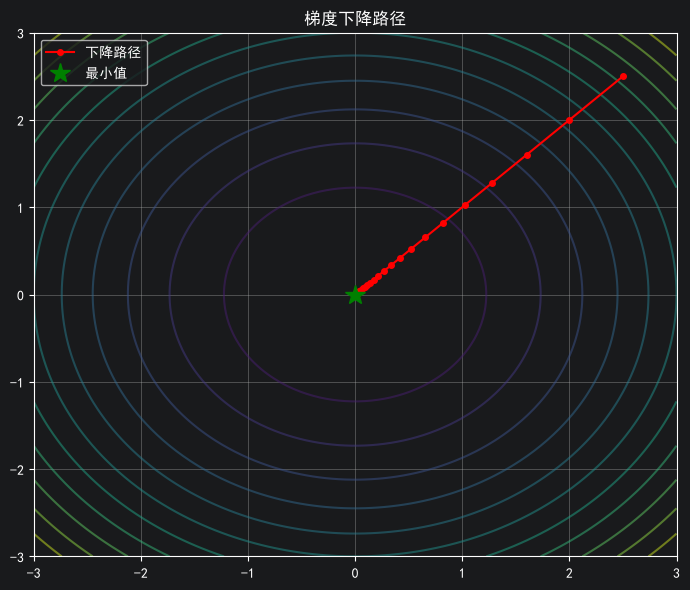

In [54]:
path = np.array(path)
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x, y)

Z = X ** 2 + Y ** 2

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(X, Y, Z, 15, cmap='viridis', alpha=0.5)
ax.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='下降路径')
ax.plot(0, 0, "g*", markersize=15, label='最小值')
ax.set_title('梯度下降路径')
ax.legend()
ax.grid(visible=True)
plt.tight_layout()
plt.show()